In [91]:
# =============================================================================
# 1. IMPORTATION DES BIBLIOTHÈQUES
# =============================================================================

# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistiques
from scipy import stats

# Régression linéaire
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Diagnostics
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Ignorer les warnings
import warnings
warnings.filterwarnings("ignore")

# Paramètres graphiques
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10,6)

# Affichage des décimales
pd.set_option("display.float_format", lambda x: "%.2f" % x)

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


In [92]:
# =============================================================================
# 2. CHARGEMENT DES DONNÉES
# =============================================================================

df = pd.read_csv(r"D:\M2\DATA-SCIENCE\INOHA-DataScience-M2/donnees_mpox_RDC_3000.csv")

In [93]:
# verification doublon 
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0


In [94]:
# Vérification des vars num et quali
missing = pd.DataFrame({

    "Valeurs_manquantes": df.isna().sum(),

    "Pourcentage": round(df.isna().mean()*100,2)

})

missing.sort_values("Pourcentage", ascending=False)

,Valeurs_manquantes,Pourcentage
ID,0,0.00
Semaine,0,0.00
Province,0,0.00
Pluviometrie_mm,0,0.00
Temperature_C,0,0.00
NDVI,0,0.00
Humidite_pct,0,0.00
Densite_Population,0,0.00
Couverture_Vaccinale_pct,0,0.00
Tests_Realises,0,0.00


In [95]:
# =============================================================================
# 3. ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
# =============================================================================

print("="*70)
print("ANALYSE EXPLORATOIRE DES DONNÉES")
print("="*70)

# Dimensions
print(f"\nNombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

# Informations générales
print("\nInformations générales")
df.info()

# Statistiques descriptives
print("\nRésumé statistique")
display(df.describe())

# Variables qualitatives
print("\nVariables qualitatives")
display(df.describe(include="object"))

ANALYSE EXPLORATOIRE DES DONNÉES

Nombre de lignes : 3000
Nombre de colonnes : 17

Informations générales
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        3000 non-null   str    
 1   Semaine                   3000 non-null   int64  
 2   Province                  3000 non-null   str    
 3   Pluviometrie_mm           3000 non-null   int64  
 4   Temperature_C             3000 non-null   float64
 5   NDVI                      3000 non-null   float64
 6   Humidite_pct              3000 non-null   int64  
 7   Densite_Population        3000 non-null   int64  
 8   Couverture_Vaccinale_pct  3000 non-null   float64
 9   Tests_Realises            3000 non-null   int64  
 10  Distance_Centre_Sante_km  3000 non-null   int64  
 11  Reservoirs_Animaux        3000 non-null   int64  
 12  Mobilite_Humaine       

,Semaine,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Population_Risque,Taux_Positivite_pct
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,1500.50,157.78,24.98,0.45,71.57,119.10,31.84,286.14,15.56,0.40,5.02,79.60,5471.30,27.04
std,866.17,101.96,3.83,0.16,11.63,95.22,14.08,88.26,15.14,0.49,1.95,70.12,2636.19,20.16
min,1.00,2.00,18.00,0.10,40.00,5.00,5.60,90.00,1.00,0.00,1.00,0.00,1001.00,0.00
25%,750.75,77.00,22.30,0.33,64.00,48.00,20.80,220.00,5.00,0.00,4.00,29.00,3127.00,11.43
50%,1500.50,136.00,24.90,0.45,71.50,94.00,30.40,280.00,11.00,0.00,5.00,57.00,5514.50,21.45
75%,2250.25,221.00,27.60,0.58,80.00,163.00,41.52,340.00,22.00,1.00,6.00,109.00,7819.25,38.07
max,3000.00,400.00,34.00,0.80,95.00,500.00,77.80,800.00,142.00,1.00,10.00,479.00,9997.00,95.00



Variables qualitatives


,ID,Province,Saison
count,3000,3000,3000
unique,3000,26,2
top,OBS_00001,Kongo Central,Pluie
freq,1,132,1931


In [96]:
df

,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,OBS_00001,1,Mongala,206,24.40,0.48,64,39,31.80,150,22,1,4,29,Pluie,3478,19.33
1,OBS_00002,2,Kinshasa,56,23.70,0.47,74,107,24.90,300,5,1,6,42,Seche,3713,14.00
2,OBS_00003,3,Kinshasa,59,25.20,0.33,62,140,53.90,310,16,0,8,20,Seche,4833,6.45
3,OBS_00004,4,Mai-Ndombe,396,24.10,0.35,68,97,25.90,210,4,0,10,82,Pluie,3777,39.05
4,OBS_00005,5,Kasaï,127,19.80,0.30,61,86,30.30,260,24,1,6,24,Pluie,9396,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,OBS_02996,2996,Kongo Central,271,31.60,0.53,88,57,22.40,220,33,1,7,125,Pluie,3166,56.82
2996,OBS_02997,2997,Sud-Ubangi,88,24.60,0.26,95,47,34.10,370,7,1,6,70,Seche,6099,18.92
2997,OBS_02998,2998,Bas-Uele,268,25.60,0.72,58,18,41.90,190,23,0,2,36,Pluie,5475,18.95
2998,OBS_02999,2999,Haut-Uele,211,24.90,0.20,77,28,10.60,370,2,0,2,160,Pluie,4813,43.24


In [97]:
# =============================================================================
# VARIABLES CATÉGORIELLES
# =============================================================================

cat_var = df.select_dtypes(exclude=np.number).columns

print(cat_var)

Index(['ID', 'Province', 'Saison'], dtype='str')


In [98]:
# =============================================================================
# VARIABLES NUMÉRIQUES
# =============================================================================

num_var = df.select_dtypes(include=np.number).columns

print(num_var)

Index(['Semaine', 'Pluviometrie_mm', 'Temperature_C', 'NDVI', 'Humidite_pct',
       'Densite_Population', 'Couverture_Vaccinale_pct', 'Tests_Realises',
       'Distance_Centre_Sante_km', 'Reservoirs_Animaux', 'Mobilite_Humaine',
       'Cas_Confirmes', 'Population_Risque', 'Taux_Positivite_pct'],
      dtype='str')


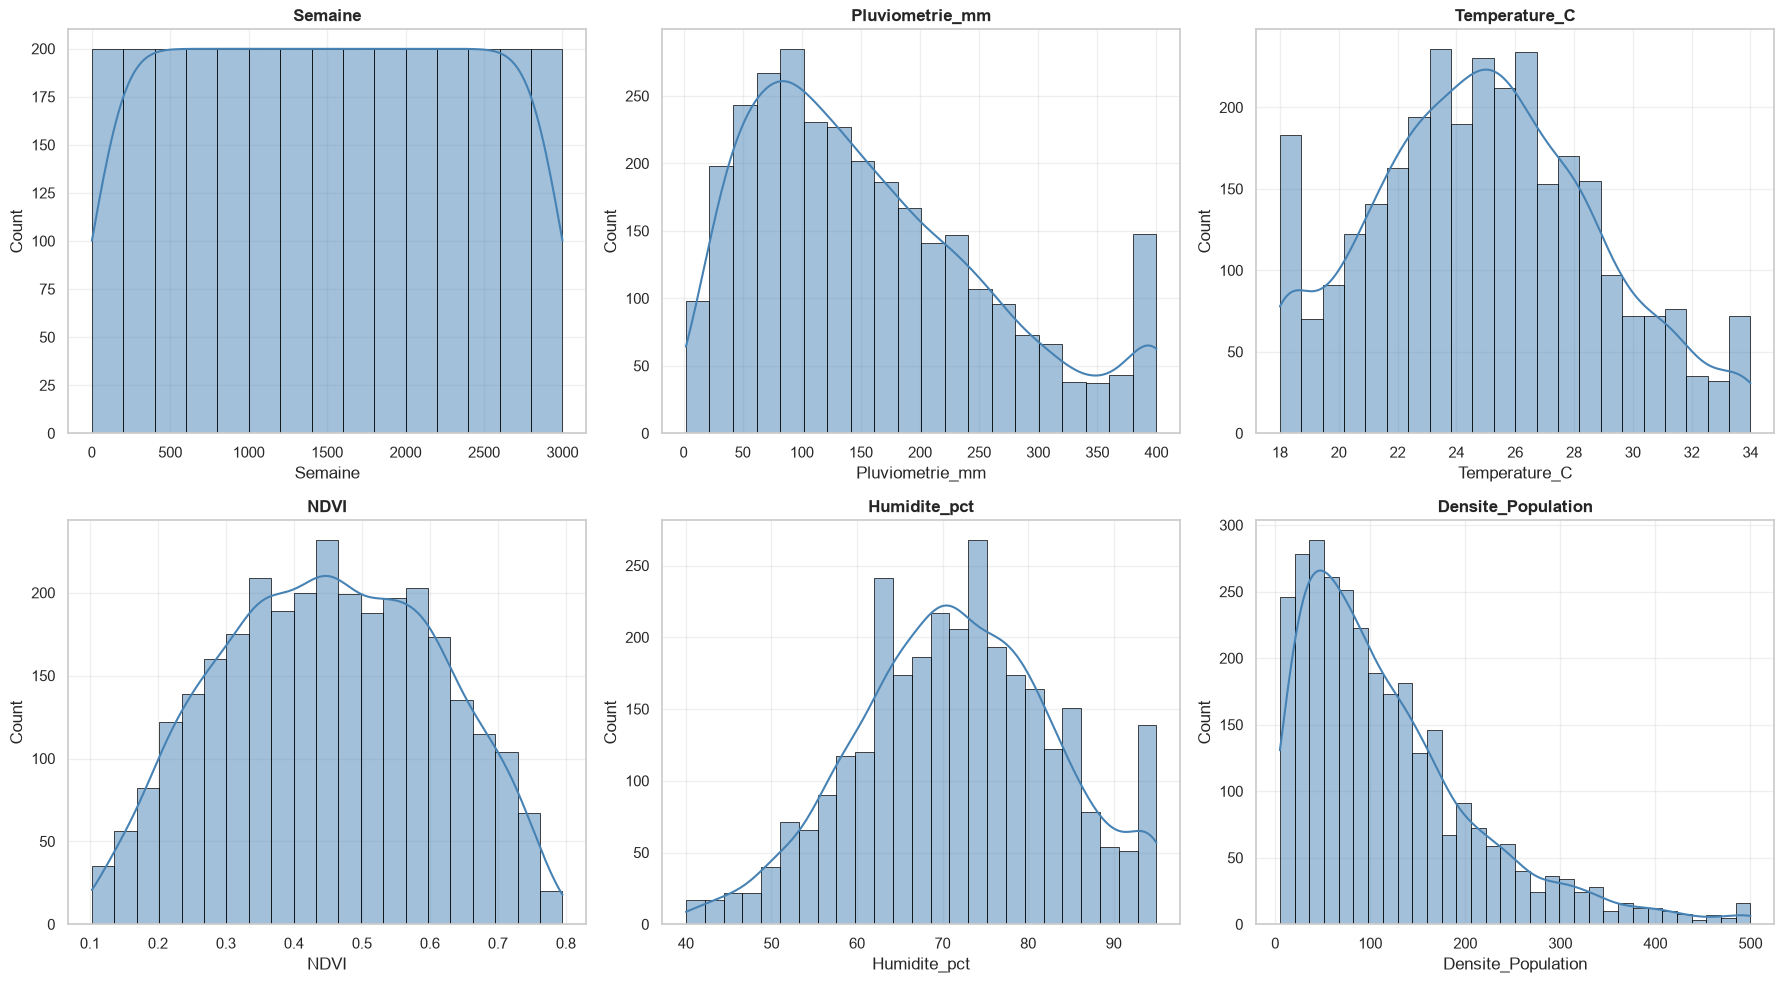

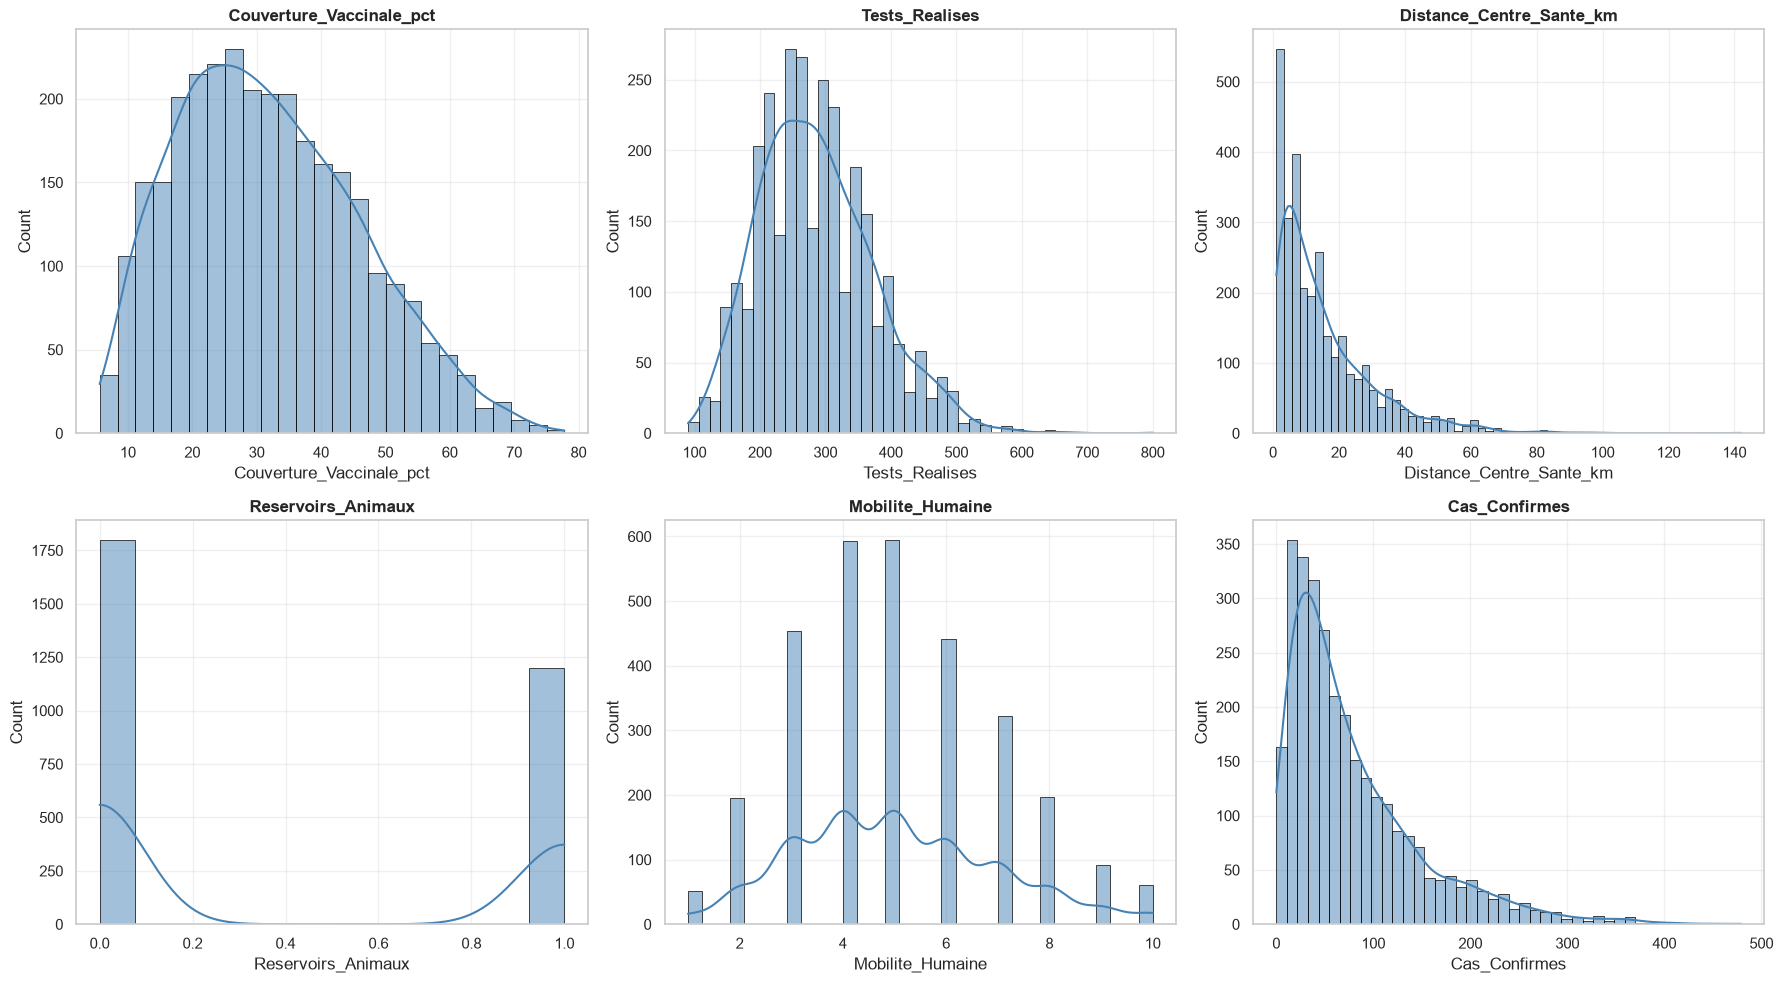

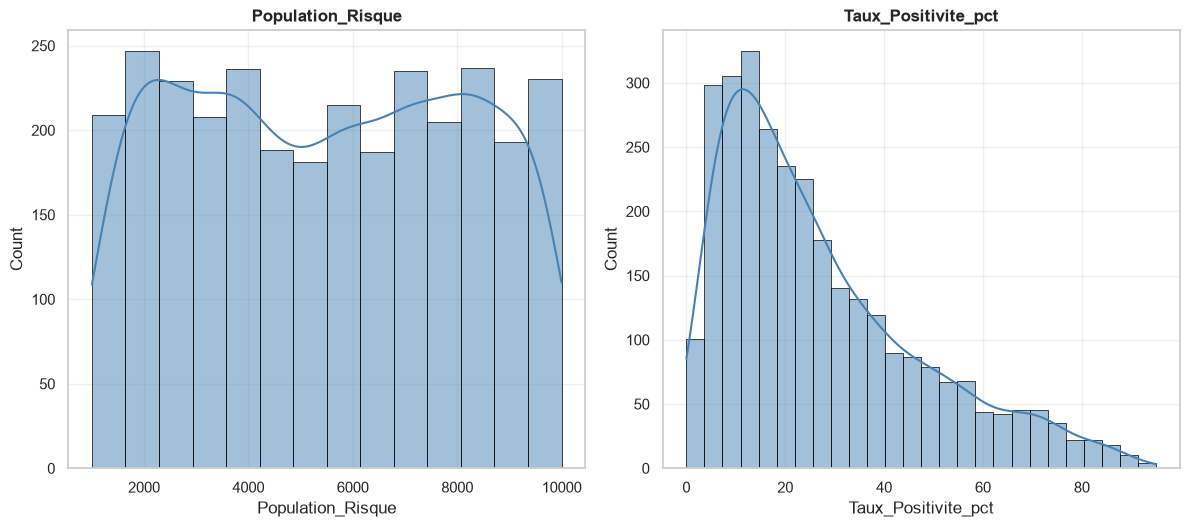

In [99]:
# =============================================================================
# HISTOGRAMMES (3 colonnes × 2 lignes = 6 graphiques)
# =============================================================================

num_var = df.select_dtypes(include=np.number).columns

ncols = 3
nrows = 2
plots_par_page = ncols * nrows

for debut in range(0, len(num_var), plots_par_page):

    subset = num_var[debut:debut + plots_par_page]

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 10))

    axes = axes.flatten()

    for ax, col in zip(axes, subset):

        sns.histplot(
            data=df,
            x=col,
            kde=True,
            color="steelblue",
            edgecolor="black",
            linewidth=0.5,
            ax=ax
        )

        ax.set_title(col, fontsize=12, fontweight="bold")
        ax.grid(alpha=0.3)

    # Supprimer les axes inutilisés
    for ax in axes[len(subset):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

#### Interprétations 
- Semaine : La distribution est relativement uniforme sur l'ensemble de la période d'étude, indiquant que les observations sont réparties de manière homogène au cours du temps, sans concentration particulière sur certaines semaines.

- Pluviométrie (mm) : La distribution présente une asymétrie positive (queue vers les valeurs élevées). La majorité des observations correspond à des niveaux de précipitations faibles à modérés, tandis que les fortes précipitations sont moins fréquentes.

- Température (°C) : La distribution est proche d'une distribution normale, centrée autour de 25–26 °C. Les températures sont relativement stables durant la période étudiée, avec peu de valeurs extrêmes.

- NDVI : L'indice de végétation présente une distribution relativement symétrique, avec une concentration des observations autour des valeurs intermédiaires (≈ 0,4–0,6), traduisant une couverture végétale globalement homogène dans la zone d'étude.

- Humidité (%) : La distribution est légèrement asymétrique vers les faibles valeurs, mais la majorité des observations est concentrée entre 65 % et 80 %, indiquant une humidité relativement élevée pendant la période d'étude.

- Densité de population : La distribution est fortement asymétrique à droite. La majorité des observations concerne des zones faiblement peuplées, tandis qu'un faible nombre de zones présente des densités de population très élevées, ce qui est caractéristique des données démographiques.

- Couverture vaccinale (%) : La distribution est asymétrique à droite. La majorité des observations correspond à une couverture vaccinale faible à modérée, tandis que les couvertures très élevées sont plus rares.

- Tests réalisés : La distribution présente une asymétrie positive marquée. La plupart des observations concernent un nombre modéré de tests réalisés, alors que quelques observations correspondent à des campagnes de dépistage beaucoup plus importantes.

- Distance au centre de santé (km) : La distribution est fortement asymétrique à droite. La majorité des populations est située à proximité des centres de santé, tandis que seules quelques localités sont localisées à de grandes distances.

- Réservoirs animaux : Cette variable étant binaire (0 = absence, 1 = présence), l'histogramme montre les effectifs des deux modalités. Les deux catégories sont bien représentées dans la base de données, ce qui permettra d'évaluer leur influence dans les modèles statistiques.

- Mobilité humaine : La distribution est centrée autour des niveaux de mobilité intermédiaires (4 à 6), avec une dispersion relativement faible. Les niveaux très faibles ou très élevés de mobilité sont moins fréquents.

- Cas confirmés : La distribution est fortement asymétrique à droite. La majorité des observations présente un faible nombre de cas confirmés, tandis qu'un nombre limité d'observations concentre des effectifs beaucoup plus élevés.

- Population à risque : La distribution est relativement homogène sur l'intervalle étudié, sans concentration marquée autour d'une valeur particulière, ce qui traduit une variabilité importante de la population exposée selon les observations.

- Taux de positivité (%) : La distribution présente une asymétrie positive. Les faibles taux de positivité sont les plus fréquents, tandis que les valeurs élevées restent plus rares et peuvent correspondre à des périodes de transmission plus intense.

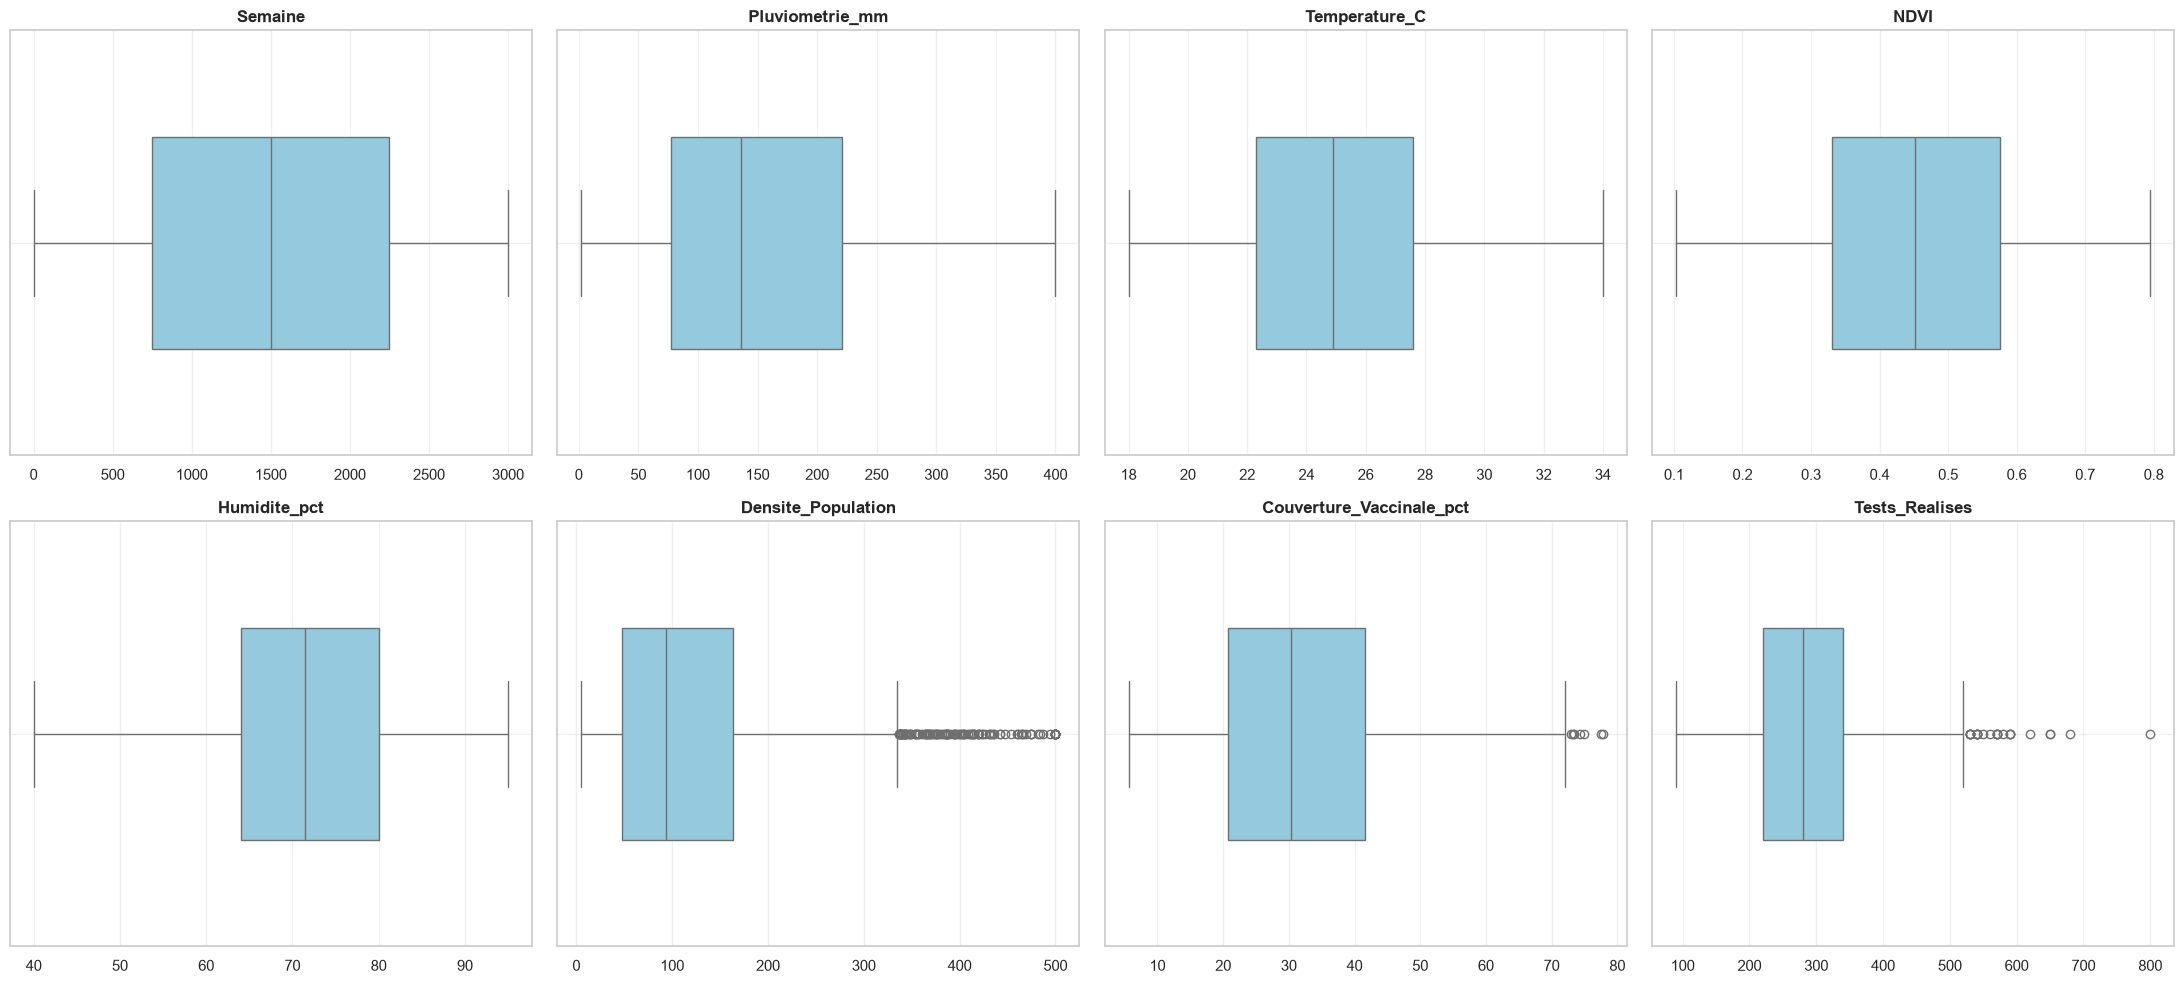

In [100]:
# =============================================================================
# BOXPLOTS (4 colonnes × 2 lignes = 8 graphiques)
# =============================================================================



num_var = df.select_dtypes(include=np.number).columns

ncols = 4
nrows = 2
plots_par_page = ncols * nrows

for debut in range(0, len(
cat_var), plots_par_page):

    subset = num_var[debut:debut + plots_par_page]

    fig, axes = plt.subplots(nrows, ncols, figsize=(22, 10))

    axes = axes.flatten()

    for ax, col in zip(axes, subset):

        sns.boxplot(
            x=df[col],
            color="skyblue",
            width=0.5,
            ax=ax
        )

        ax.set_title(col, fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.grid(alpha=0.3)

    # Supprimer les sous-graphes inutilisés
    for ax in axes[len(subset):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

#### Interprétations 
- la variable semaine couvre correctement l'ensemble de la période d'étude sans concentration particulière.
- pour la pluviometrie, les prélèvements varient fortement selon les observations, ce qui est attendu dans un contexte climatique. 
- La température reste relativement stable durant la période étudiée. 
- L'humidité relative varie modérément entre les différentes observations. 
- Densité: Quelques zones présentent une densité de population très élevée alors que la majorité possède une faible densité. Cette distribution est typique des données démographiques. 
- Couverture vaccinale, La plupart des zones possèdent une couverture vaccinale comparable, mais certaines atteignent des niveaux exceptionnellement élevés.
- Tests realisés : Quelques zones ont réalisé beaucoup plus de tests que les autres, probablement en raison d'une surveillance renforcée ou d'un nombre élevé de cas suspects.Très nombreux cas aberrants et la distribution fortement asymétrique à droite. 
- Distance au centre de santé : La majorité des populations est située relativement près d'un centre de santé, tandis que certaines localités sont beaucoup plus éloignées. très forte asymétrie, de nombreuses valeurs aberrantes. 
- La mobilité humaine présente une variabilité modérée entre les observations. Légère asymétrie, peu d'outliers. 
- La majorité des observations présente un faible nombre de cas confirmés, tandis qu'un petit nombre de semaines ou de provinces concentre des nombres de cas très élevés. Cette distribution est caractéristique des données de comptage épidémiologiques. Cette observation suggère que les données ne suivent probablement pas une distribution normale, ce qui justifie la comparaison entre un modèle de régression linéaire et un modèle de régression de Poisson (ou binomiale négative si une surdispersion est mise en évidence). 
- La population à risque varie fortement selon les observations, mais sans valeurs extrêmes isolées. 
- Taux de positivité: La plupart des observations présentent un faible taux de positivité, alors que quelques épisodes atteignent des taux très élevés, pouvant correspondre à des périodes de forte transmission.

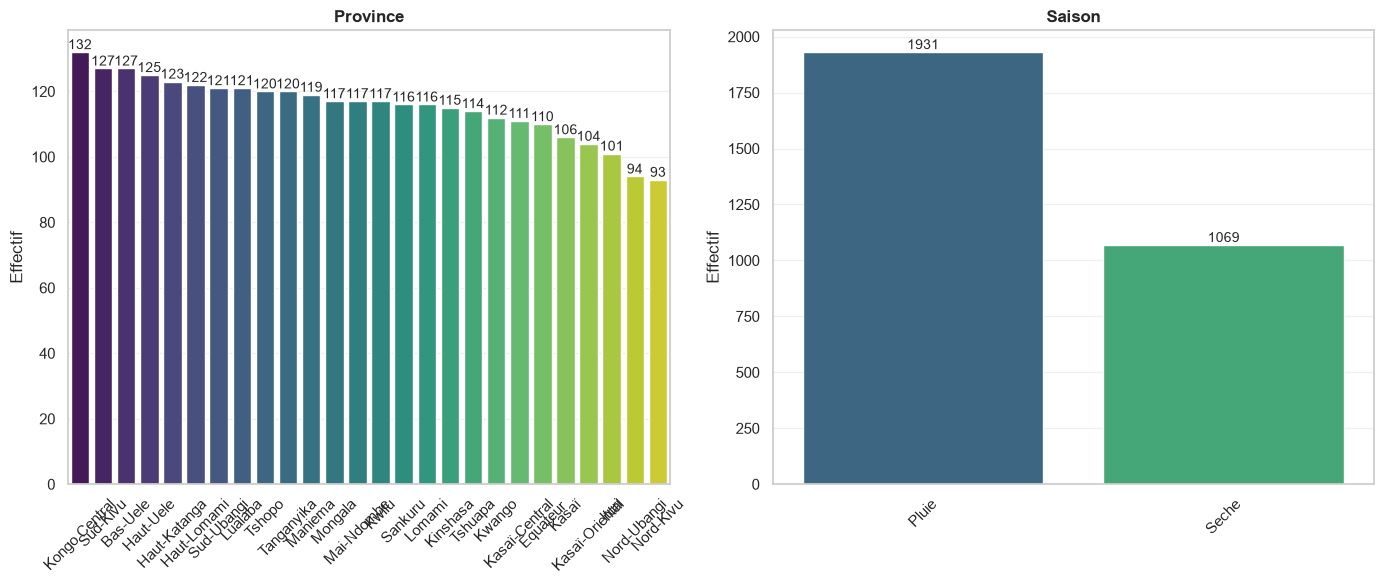

In [101]:
# =============================================================================
# VARIABLES CATÉGORIELLES (COUNTPLOTS)
# =============================================================================

# Exclure la variable ID
cat_var = ['Province', 'Saison']

ncols = 2
nrows = 1
plots_par_page = ncols * nrows

for debut in range(0, len(cat_var), plots_par_page):

    subset = cat_var[debut:debut + plots_par_page]

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 6))

    # Si une seule variable
    if len(subset) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax, col in zip(axes, subset):

        ordre = df[col].value_counts().index

        sns.countplot(
            data=df,
            x=col,
            order=ordre,
            palette="viridis",
            ax=ax
        )

        ax.set_title(col, fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Effectif")
        ax.tick_params(axis='x', rotation=45)

        # Afficher les effectifs sur les barres
        for container in ax.containers:
            ax.bar_label(container, fontsize=10)

        ax.grid(axis='y', alpha=0.3)

    # Supprimer les axes inutilisés
    for ax in axes[len(subset):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

#### Interprétations 
- Province : Le diagramme en barres montre que les observations sont réparties entre les différentes provinces de la République Démocratique du Congo avec des effectifs relativement proches, compris entre 93 et 132 observations par province. Cette répartition relativement équilibrée limite le risque qu'une province soit surreprésentée dans les analyses statistiques et permet une comparaison plus fiable entre les provinces.
- Saison : La variable Saison est composée de deux modalités : la saison des pluies et la saison sèche. La majorité des observations a été enregistrée pendant la saison des pluies (1 931 observations, soit environ 64,4 %), contre 1 069 observations (35,6 %) pendant la saison sèche. Cette différence traduit une prédominance des données collectées durant la saison des pluies. Cette répartition devra être prise en compte lors de l'interprétation des résultats, dans la mesure où les conditions climatiques saisonnières peuvent influencer la dynamique de transmission de la maladie.

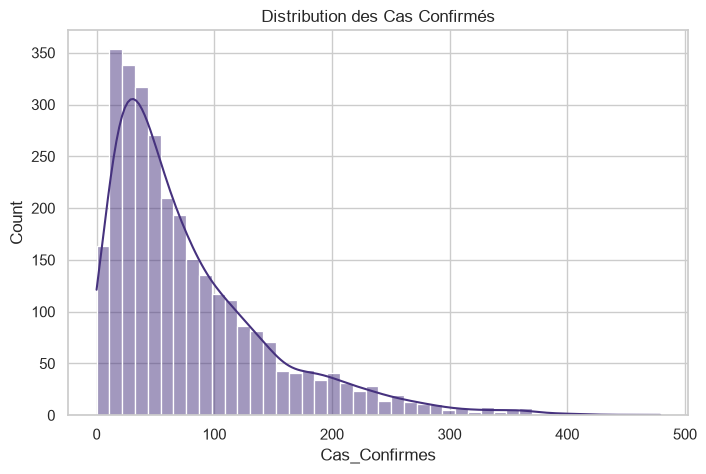

count   3000.00
mean      79.60
std       70.12
min        0.00
25%       29.00
50%       57.00
75%      109.00
max      479.00
Name: Cas_Confirmes, dtype: float64


In [102]:
# =============================================================================
# VARIABLE CIBLE
# =============================================================================

plt.figure(figsize=(8,5))

sns.histplot(df["Cas_Confirmes"], kde=True)

plt.title("Distribution des Cas Confirmés")

plt.show()

print(df["Cas_Confirmes"].describe())

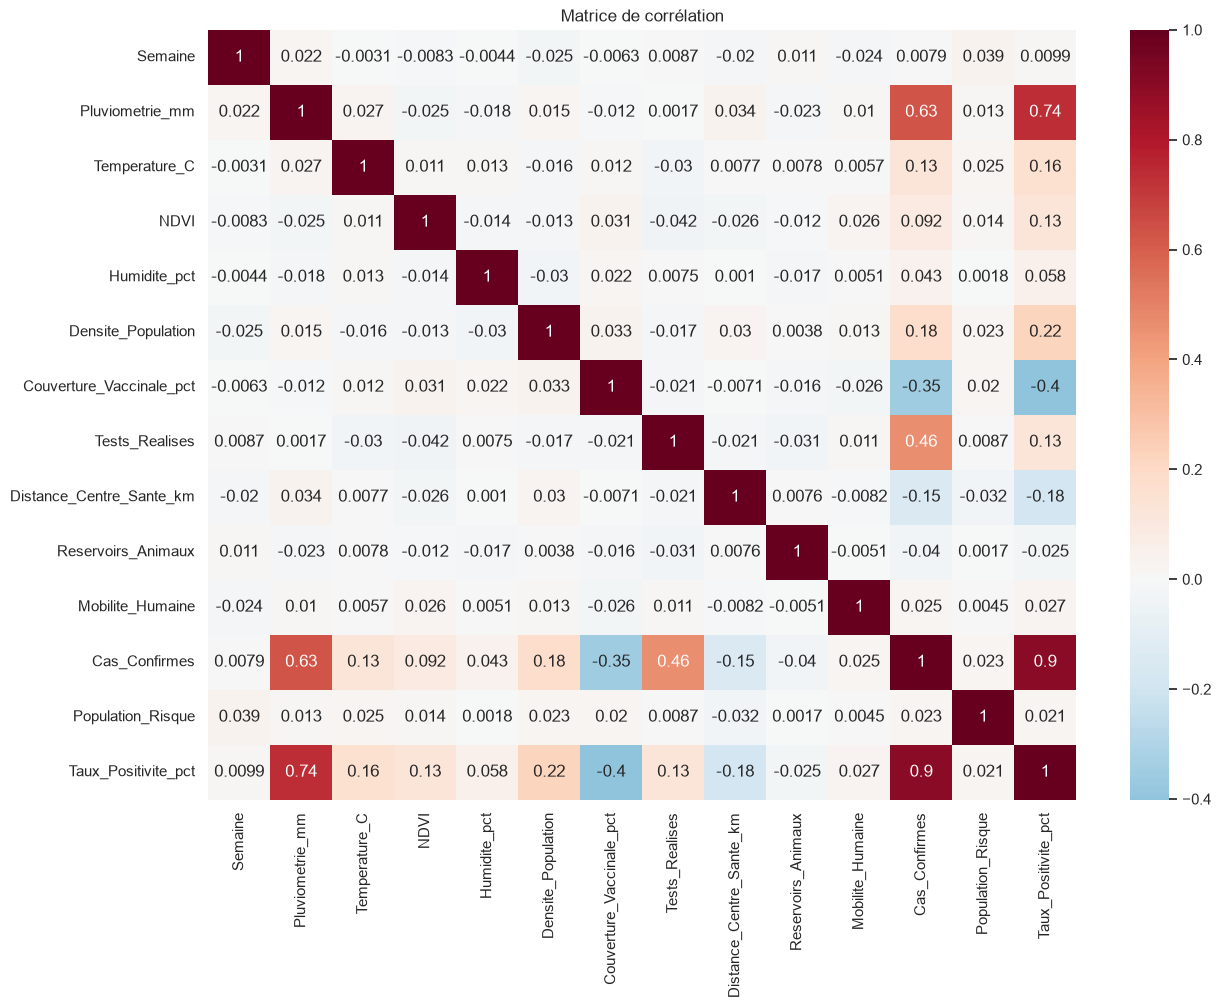

In [103]:
# =============================================================================
# MATRICE DE CORRÉLATION
# =============================================================================

corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(14,10))

sns.heatmap(corr,
            annot=True,
            cmap="RdBu_r",
            center=0)

plt.title("Matrice de corrélation")

plt.show()

In [104]:
# =============================================================================
# CORRÉLATION AVEC LA VARIABLE CIBLE
# =============================================================================

corr_target = corr["Cas_Confirmes"].sort_values(ascending=False)

display(corr_target)

Cas_Confirmes               1.00
Taux_Positivite_pct         0.90
Pluviometrie_mm             0.63
Tests_Realises              0.46
Densite_Population          0.18
Temperature_C               0.13
NDVI                        0.09
Humidite_pct                0.04
Mobilite_Humaine            0.02
Population_Risque           0.02
Semaine                     0.01
Reservoirs_Animaux         -0.04
Distance_Centre_Sante_km   -0.15
Couverture_Vaccinale_pct   -0.35
Name: Cas_Confirmes, dtype: float64

##### Interprétation des corrélations avec Cas_Confirmes

L'analyse des coefficients de corrélation montre que plusieurs variables présentent des degrés d'association différents avec le nombre de cas confirmés.

La variable Taux_Positivite_pct présente la corrélation positive la plus élevée avec les cas confirmés ( r = 0,90 ), traduisant une très forte relation linéaire positive. Cela indique qu'une augmentation du taux de positivité est fortement associée à une augmentation du nombre de cas confirmés, ce qui est cohérent d'un point de vue épidémiologique.

La Pluviométrie_mm présente également une corrélation positive relativement forte ( r = 0,63 ), suggérant que les périodes de fortes retenues sont associées à une augmentation du nombre de cas confirmés. Cette relation pourrait refléter l'influence des conditions climatiques sur la dynamique de transmission.

Le nombre de Tests_Réalisés est modérément corrélé aux cas confirmés ( r = 0,46 ). Cette relation est attendue puisque l'augmentation des activités de dépistage favorise l'identification des cas.

Les variables Densite_Population ( r = 0,18 ), Temperature_C ( r = 0,13 ), NDVI ( r = 0,09 ), Humidite_pct ( r = 0,04 ), Mobilite_Humaine ( r = 0,02 ), Population_Risque ( r = 0,02 ) et Semaine ( r = 0,01 ) présentent des corrélations faibles avec les cas confirmés. Individuellement, elles semblent exercer une influence limitée sur la variable dépendante.

À l'inverse, Couverture_Vaccinale_pct présente une corrélation négative modérée ( r = -0,35 ). Cette relation indique qu'une meilleure couverture vaccinale est associée à une diminution du nombre de cas confirmés, ce qui est compatible avec l'effet protecteur attendu de la vaccination.

La variable Distance_Centre_Sante_km présente une faible corrélation négative ( r = -0,15 ), suggérant que les zones plus éloignées des centres de santé rapportent légèrement moins de cas confirmés. Cette relation peut refléter une sous-détection des cas liés à un accès plus difficile aux services de santé plutôt qu'une réduction réelle de la transmission.

Enfin, la variable Reservoirs_Animaux montre une corrélation très faible et négative ( r = -0,04 ), indiquant l'absence de relation linéaire notable avec le nombre de cas confirmés dans les données étudiées.

Concernant la variable Taux_Positivite_pct, etant donné qu'on ne maitrise pas comment elle a été construite, nous l'excluons de modèle car àa peut apporter le biais lié ç l'information

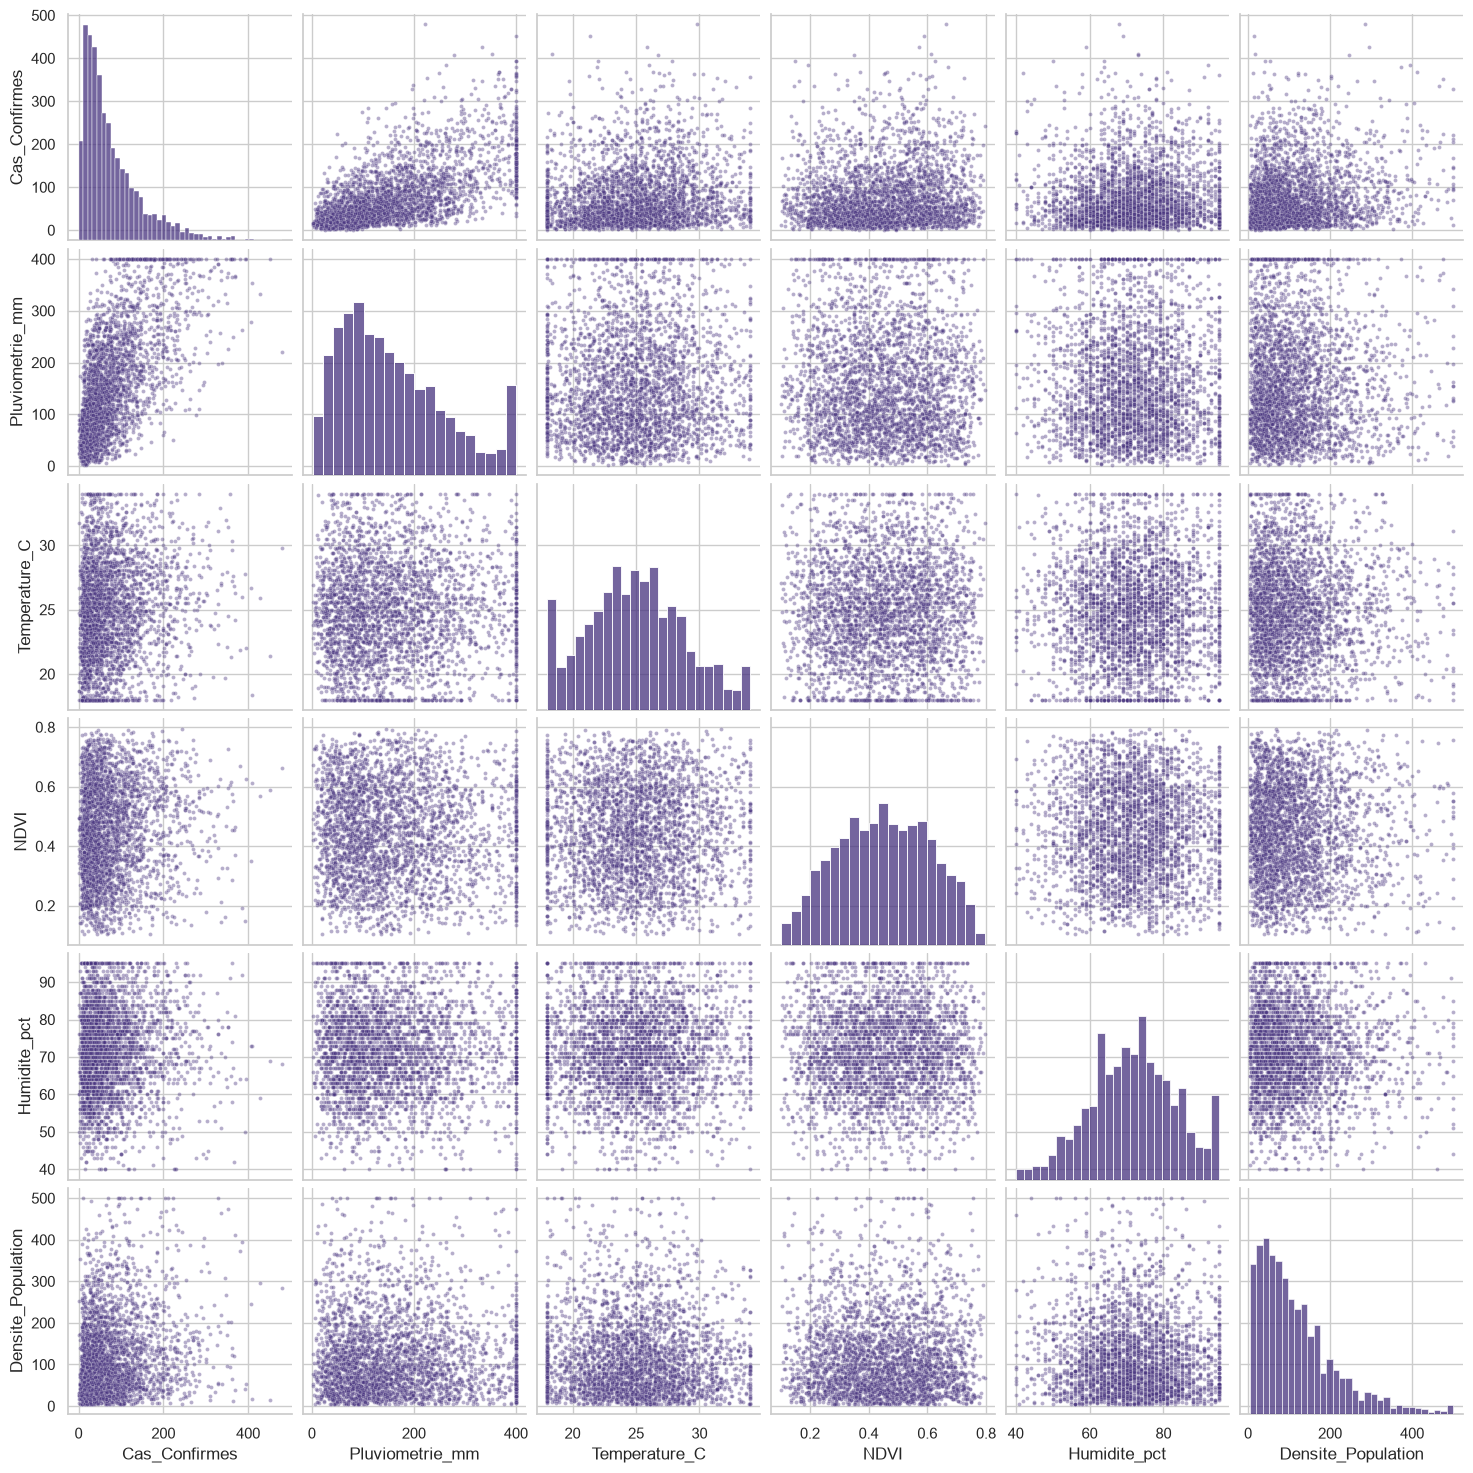

In [105]:
# Matrice de dispersion 
variables = [
    "Cas_Confirmes",
    "Pluviometrie_mm",
    "Temperature_C",
    "NDVI",
    "Humidite_pct",
    "Densite_Population"
]

sns.pairplot(
    df[variables],
    diag_kind="hist",
    plot_kws={"s": 8, "alpha": 0.4}
)
plt.show()

#### Interpreatations
La matrice de dispersion permet d'examiner simultanément la distribution des variables numériques (histogrammes sur la diagonale) et les relations bivariées entre les variables explicatives et la variable dépendante Cas_Confirmes.

Les histogrammes situés sur la diagonale confirment les observations précédentes. Les variables Cas_Confirmes, Pluviometrie_mm et Densite_Population présentent une asymétrie positive marquée, tandis que Temperature_C, NDVI et Humidite_pct montrent des distributions plus proches d'une distribution symétrique.

L'examen des nuages de points met en évidence les observations suivantes :

Cas_Confirmes – Pluviometrie_mm : une tendance positive est observée. Les valeurs élevées de pluviométrie semblent être associées à une augmentation du nombre de cas confirmés, bien que la dispersion des observations reste importante.
Cas_Confirmes – Temperature_C : le nuage de points ne révèle pas de tendance linéaire nette, suggérant une faible association entre la température et le nombre de cas confirmés.
Cas_Confirmes – NDVI : aucune relation linéaire évidente n'est observée. Les cas confirmés sont répartis sur l'ensemble des valeurs de NDVI, indiquant une faible corrélation.
Cas_Confirmes – Humidite_pct : la dispersion des observations est importante et ne met pas en évidence de relation linéaire marquée entre l'humidité relative et le nombre de cas confirmés.
Cas_Confirmes – Densite_Population : une légère tendance positive peut être observée, mais la forte dispersion des points indique que la densité de population, prise isolément, explique une faible proportion de la variabilité des cas confirmés.

Par ailleurs, les relations entre les variables explicatives apparaissent globalement dispersées, sans alignement marqué des observations. Cela suggère l'absence de relations linéaires très fortes entre ces variables, ce qui constitue un premier indice d'une faible multicolinéarité. Toutefois, cette hypothèse devra être confirmée par le calcul du facteur d'inflation de variance (VIF) avant l'ajustement du modèle de régression multiple.

In [106]:
# vérification de la construction de taux de positivité 
df[['Cas_Confirmes', 'Tests_Realises', 'Taux_Positivite_pct']].head(10)

,Cas_Confirmes,Tests_Realises,Taux_Positivite_pct
0,29,150,19.33
1,42,300,14.00
2,20,310,6.45
3,82,210,39.05
4,24,260,9.23
5,241,340,70.88
6,174,310,56.13
7,144,300,48.00
8,178,240,74.17
9,16,190,8.42


De ce resultat, nous excluons la variable Taux_positivite pour la modélisation envie d'éviter le biais d'information, car elle est  construite les deux varaibles ci-dessus qui seront dans le modèle : cas confirmé/Tests_Realise *100

In [107]:
# =============================================================================
# 4. PRÉTRAITEMENT DES DONNÉES
# =============================================================================

print("="*70)
print("PRÉTRAITEMENT DES DONNÉES")
print("="*70)

# Suppression des variables inutiles
df_model = df.drop(columns=["ID", "Province", "Taux_Positivite_pct"])

# Encodage de la saison
df_model["Saison"] = df_model["Saison"].map({
    "Pluie": 0,
    "Seche": 1
})

# Variables
y = df_model["Cas_Confirmes"]
X = df_model.drop(columns=["Cas_Confirmes"])



# Variable dépendante
y = df_model["Cas_Confirmes"]

# Variables explicatives
X = df_model.drop(columns=["Cas_Confirmes"])

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

PRÉTRAITEMENT DES DONNÉES
Dimensions de X : (3000, 13)
Dimensions de y : (3000,)


In [108]:
df_model

,Semaine,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque
0,1,206,24.40,0.48,64,39,31.80,150,22,1,4,29,0,3478
1,2,56,23.70,0.47,74,107,24.90,300,5,1,6,42,1,3713
2,3,59,25.20,0.33,62,140,53.90,310,16,0,8,20,1,4833
3,4,396,24.10,0.35,68,97,25.90,210,4,0,10,82,0,3777
4,5,127,19.80,0.30,61,86,30.30,260,24,1,6,24,0,9396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,271,31.60,0.53,88,57,22.40,220,33,1,7,125,0,3166
2996,2997,88,24.60,0.26,95,47,34.10,370,7,1,6,70,1,6099
2997,2998,268,25.60,0.72,58,18,41.90,190,23,0,2,36,0,5475
2998,2999,211,24.90,0.20,77,28,10.60,370,2,0,2,160,0,4813


In [114]:
# =============================================================================
# VÉRIFICATION DE LA MULTICOLINÉARITÉ (VIF)
# =============================================================================

# Calcul du VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Ajout de la constante
X_vif = add_constant(X)

# Calcul du VIF
vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i)
              for i in range(X_vif.shape[1])]

vif

,Variable,VIF
0,const,130.24
1,Semaine,1.00
2,Pluviometrie_mm,2.08
3,Temperature_C,1.00
4,NDVI,1.01
5,Humidite_pct,1.00
6,Densite_Population,1.01
7,Couverture_Vaccinale_pct,1.01
8,Tests_Realises,1.01
9,Distance_Centre_Sante_km,1.00


#### Interpretation 
Le facteur d'inflation de la variance (VIF) est calculé afin d'évaluer la présence d'une multicolinéarité entre les variables explicatives. Les résultats montrent que les valeurs de VIF varient entre 1,00 et 2,08, en excluant la constante qui n'est pas interprétée. Toutes les variables présentent un VIF largement inférieur au seuil de 5, indiquant l'absence de multicolinéarité préoccupante. La pluviométrie et la saison affichent les valeurs les plus élevées (VIF = 2,08), ce qui traduit une légère corrélation entre ces deux variables, sans toutefois compromettre la stabilité du modèle. Ainsi, aucune variable explicative n'a été exclue sur la base du diagnostic de multicolinéarité.

#### MODELISATION
#### Approche statistique  classique 

In [116]:
# =============================================================================
# DIVISION DES DONNÉES
# =============================================================================

from sklearn.model_selection import train_test_split

# Séparation des données
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Ensemble d'entraînement :", X_train.shape)
print("Ensemble de test :", X_test.shape)

Ensemble d'entraînement : (2400, 13)
Ensemble de test : (600, 13)


In [117]:
# =============================================================================
# AJUSTEMENT DU MODÈLE
# =============================================================================

from sklearn.linear_model import LinearRegression

# Création du modèle
modele = LinearRegression()

# Entraînement
modele.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0. , 0.45, 2.6 ,...,-0.13, 7.29, 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['Semaine','Pluviometrie_mm','Temperature_C',...,'Mobilite_Humaine', 'Saison','Population_Risque']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-163.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [118]:
# =============================================================================
# COEFFICIENTS DU MODÈLE
# =============================================================================

coef = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": modele.coef_
})

coef = coef.sort_values(by="Coefficient", ascending=False)

print("Intercept :", modele.intercept_)

coef

Intercept : -163.42755161207003


,Variable,Coefficient
3,NDVI,60.28
11,Saison,7.29
2,Temperature_C,2.60
1,Pluviometrie_mm,0.45
4,Humidite_pct,0.37
7,Tests_Realises,0.36
5,Densite_Population,0.14
12,Population_Risque,0.00
0,Semaine,-0.00
10,Mobilite_Humaine,-0.13


In [119]:
# =============================================================================
# ÉQUATION DU MODÈLE
# =============================================================================

print(f"Intercept = {modele.intercept_:.3f}")

for var, coef in zip(X.columns, modele.coef_):
    print(f"{var:30s} : {coef:.3f}")

Intercept = -163.428
Semaine                        : -0.001
Pluviometrie_mm                : 0.451
Temperature_C                  : 2.596
NDVI                           : 60.276
Humidite_pct                   : 0.369
Densite_Population             : 0.143
Couverture_Vaccinale_pct       : -1.729
Tests_Realises                 : 0.360
Distance_Centre_Sante_km       : -0.819
Reservoirs_Animaux             : -2.738
Mobilite_Humaine               : -0.126
Saison                         : 7.287
Population_Risque              : 0.000


In [120]:
# =============================================================================
# RÉGRESSION LINÉAIRE MULTIPLE
# =============================================================================

import statsmodels.api as sm

# Ajout de la constante
X_sm = sm.add_constant(X)

# Ajustement du modèle
modele = sm.OLS(y, X_sm).fit()

# Résumé complet
print(modele.summary())

                            OLS Regression Results                            
Dep. Variable:          Cas_Confirmes   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     1071.
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               0.00
Time:                        20:56:50   Log-Likelihood:                -14406.
No. Observations:                3000   AIC:                         2.884e+04
Df Residuals:                    2986   BIC:                         2.892e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

#### Interprétation
- Globale
Le modèle de régression linéaire multiple explique 82,3 % de la variabilité du nombre de cas confirmés (R² = 0,823). Le test global du modèle est hautement significatif (F = 1071 ; p < 0,001), indiquant qu'au moins une des variables explicatives est significativement associée au nombre de cas confirmés.
- Coefficients
 -semaine: n'est pas statistiquement significative car la p_value est de 0.323 superieur au seuil de 0.005, donc en présence des autres variables celle-ci n'apporte aucune infomation sur le cas confirmés 
 - Pluviométrie : β = 0,4528, p < 0,001
 Pour une augmentation de 1 mm de pluie est associée, en moyenne, à une augmentation de 0,45 cas confirmé, toutes choses égales par ailleurs(lorsque toute autres variable reste constante).
 - Temperature: Pour une  augmentation de 1 °C  de temperature ,le cas confirmés augementent d'une moyenne de 2,47 
 -NDVI : Le coefficient semble élevé, le NDVI varie généralement entre 0 et 1. Donc pour une augmentation de 0,1 unité de NDVI correspond donc à : 0,1×59,77≈5,98, soit environ 6 cas supplémentaires. Donc pour uen augmentation de 0.1 unité de NDVI, il ya une augmentation d'environ 6 cas confirmés
 - Couverture vaccinalle Une augmentation d'un point de pourcentage de la couverture vaccinale est associée à une diminution moyenne de 1,74 cas confirmé.
 _ Distance : Plus la distance augmente, moins de cas confirmés sont observés de -0,795. Cela peut refléter un moindre accès au dépistage ou aux structures de santé, plutôt qu'un risque biologique plus faible.
 - Reservoire: la variable etant catégorielle, donc l'interpretation se fait par rapport au changement de classe( lorsqu'on quitte de la classe de presence de reservoir pour celle d'absence de reservoir, le ca confirmés diminuent en moyenne -2.1776  )

In [122]:
# =============================================================================
# CALCUL DES VALEURS PRÉDITES ET DES RÉSIDUS
# =============================================================================

# Valeurs prédites
y_pred = modele.fittedvalues

# Résidus
residus = modele.resid

print("Nombre de résidus :", len(residus))

Nombre de résidus : 3000


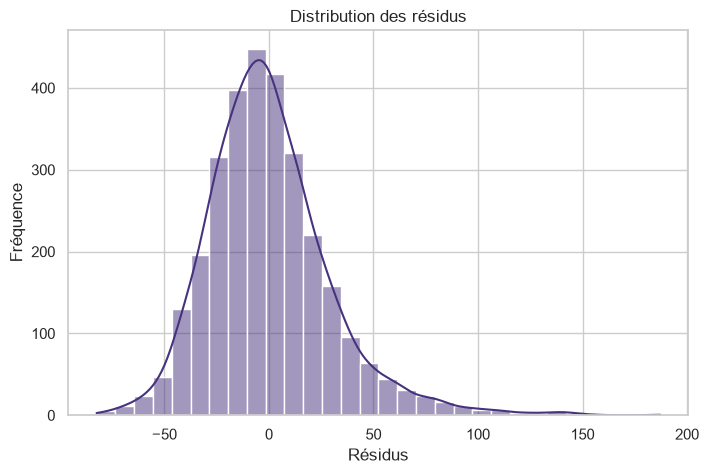

In [123]:
# =============================================================================
# HISTOGRAMME DES RÉSIDUS
# =============================================================================

plt.figure(figsize=(8,5))

sns.histplot(residus, bins=30, kde=True)

plt.title("Distribution des résidus")
plt.xlabel("Résidus")
plt.ylabel("Fréquence")

plt.show()

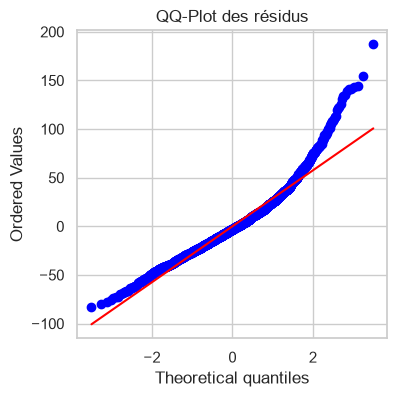

In [125]:
# =============================================================================
# QQ-PLOT DES RÉSIDUS
# =============================================================================

import scipy.stats as stats

plt.figure(figsize=(4,4))

stats.probplot(residus, dist="norm", plot=plt)

plt.title("QQ-Plot des résidus")

plt.show()

In [126]:
# =============================================================================
# TEST DE JARQUE-BERA
# =============================================================================

from scipy.stats import jarque_bera

jb, p = jarque_bera(residus)

print("Statistique JB :", jb)
print("p-value :", p)

Statistique JB : 1532.685283971639
p-value : 0.0


Le test de Jarque-Bera indique que les résidus ne suivent pas une distribution normale (JB = 1532,69 ; p < 0,001). Cette conclusion est cohérente avec les observations faites à partir de l'histogramme et du QQ-Plot.

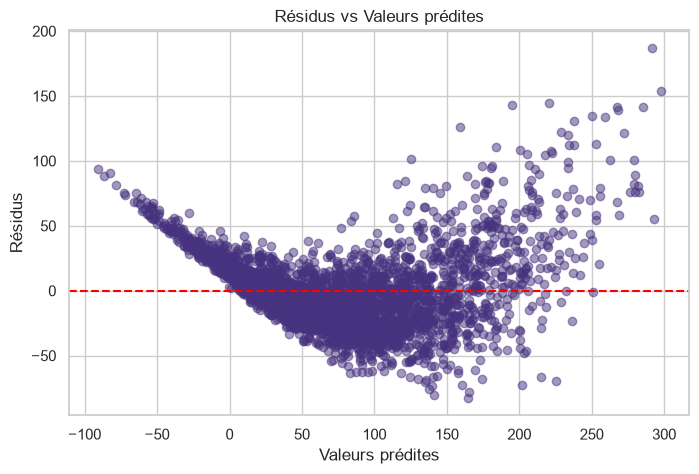

In [127]:
# =============================================================================
# HOMOSCÉDASTICITÉ
# =============================================================================

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residus, alpha=0.5)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")

plt.title("Résidus vs Valeurs prédites")

plt.show()

Cette graphique montre que les residus ne sont pas  autours de 0, d'où il y a augmentation de la dispersion lorsque les valeurs prédites augmentent. ce qui explique une variance non constante des résidus.

In [128]:
# =============================================================================
# TEST DE BREUSCH-PAGAN
# =============================================================================

from statsmodels.stats.diagnostic import het_breuschpagan

bp = het_breuschpagan(residus, modele.model.exog)

labels = [
    "LM Statistic",
    "LM-Test p-value",
    "F Statistic",
    "F-Test p-value"
]

for nom, valeur in zip(labels, bp):
    print(f"{nom} : {valeur}")

LM Statistic : 378.5807264267352
LM-Test p-value : 7.412469818887125e-73
F Statistic : 33.17175607023577
F-Test p-value : 4.009693018055595e-78


Le test de Breusch-Pagan met en évidence une hétéroscédasticité significative des résidus (LM = 378,58 ; p < 0,001), indiquant que la variance des erreurs n'est pas constante.

In [129]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(modele.resid)

print(f"Durbin-Watson : {dw:.3f}")

Durbin-Watson : 1.968


La statistique de Durbin-Watson est égale à 1,968, une valeur très proche de 2. Ce résultat indique l'absence d'autocorrélation significative des résidus. L'hypothèse d'indépendance des erreurs peut donc être considérée comme respectée.

#### Conclusion 
Les diagnostics montrent que certaines hypothèses de la régression linéaire ne sont pas entièrement respectées(Homoscedasticité et normalité des residus ). Afin de tenir compte de la nature discrète de la variable réponse (nombre de cas confirmés), un modèle de régression adapté aux données de comptage est ensuite ajusté.

#### Approche de machine learning 


In [131]:
from sklearn.model_selection import train_test_split

# Variables explicatives
X = df_model.drop(columns=["Cas_Confirmes"])

# Variable cible
y = df_model["Cas_Confirmes"]

# Séparation apprentissage / test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Taille apprentissage :", X_train.shape)
print("Taille test :", X_test.shape)

Taille apprentissage : (2400, 13)
Taille test : (600, 13)


In [132]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [133]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [135]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

# Prédictions
y_pred_lr = lr.predict(X_test)

# Métriques
mse = mean_squared_error(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

# Affichage
print(f"MSE  : {mse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MSE  : 930.797
MAE  : 22.180
RMSE : 30.509
R²   : 0.826


Le modèle de régression linéaire présente un coefficient de détermination (R²) de 0,826, indiquant qu'environ 82,6 % de la variabilité des cas confirmés est expliquée par les variables explicatives. L'erreur absolue moyenne (MAE) est de 22,18 cas, tandis que la racine de l'erreur quadratique moyenne (RMSE) est de 30,51 cas, ce qui traduit une bonne capacité prédictive globale.

In [137]:
# Ridge REGRESSION

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Modèle Ridge
ridge = Ridge(alpha=1.0)

# Entraînement (avec les données standardisées)
ridge.fit(X_train_scaled, y_train)

# Prédictions
y_pred_ridge = ridge.predict(X_test_scaled)

# Évaluation
mse = mean_squared_error(y_test, y_pred_ridge)
mae = mean_absolute_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ridge)

print(f"MSE  : {mse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MSE  : 930.913
MAE  : 22.177
RMSE : 30.511
R²   : 0.826


Les performances de la régression Ridge sont très proches de celles de la régression linéaire classique. Cette absence d'amélioration s'explique par la faible multicolinéarité observée entre les variables explicatives (VIF < 5). Dans ce contexte, la régularisation Ridge n'apporte pas de bénéfice notable.

In [138]:
# REGRESSION LASSO
from sklearn.linear_model import Lasso

# Modèle Lasso
lasso = Lasso(alpha=1.0, random_state=42)

# Entraînement
lasso.fit(X_train_scaled, y_train)

# Prédictions
y_pred_lasso = lasso.predict(X_test_scaled)

In [139]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred_lasso)
mae = mean_absolute_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lasso)

print(f"MSE  : {mse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MSE  : 949.311
MAE  : 22.039
RMSE : 30.811
R²   : 0.823


In [143]:
# Variable selectionnée par lasso
import pandas as pd

coef_lasso = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": lasso.coef_
})

coef_lasso


,Variable,Coefficient
0,Semaine,-0.00
1,Pluviometrie_mm,42.64
2,Temperature_C,8.83
3,NDVI,8.54
4,Humidite_pct,3.26
5,Densite_Population,12.55
6,Couverture_Vaccinale_pct,-23.18
7,Tests_Realises,30.55
8,Distance_Centre_Sante_km,-11.32
9,Reservoirs_Animaux,-0.36


In [ ]:
# Variable concervées
coef_lasso[coef_lasso["Coefficient"] != 0]


,Variable,Coefficient
1,Pluviometrie_mm,42.64
2,Temperature_C,8.83
3,NDVI,8.54
4,Humidite_pct,3.26
5,Densite_Population,12.55
6,Couverture_Vaccinale_pct,-23.18
7,Tests_Realises,30.55
8,Distance_Centre_Sante_km,-11.32
9,Reservoirs_Animaux,-0.36


In [ ]:
# Variable enelvées 
coef_lasso[coef_lasso["Coefficient"] == 0]

,Variable,Coefficient
0,Semaine,-0.00
10,Mobilite_Humaine,0.00
11,Saison,0.00
12,Population_Risque,0.00


#### Conclusion
Trois modèles de régression ont été évalués : la régression linéaire, Ridge et Lasso. Les résultats montrent que la régression linéaire présente les meilleures performances prédictives avec un coefficient de détermination (R²) de 0,826, un RMSE de 30,509 et un MAE de 22,180. La régression Ridge offre des performances très proches, sans amélioration notable, ce qui s'explique par la faible multicolinéarité observée entre les variables explicatives. Quant à la régression Lasso, elle présente un MAE légèrement plus faible (22,039), mais au prix d'une diminution du R² (0,823) et d'une augmentation du RMSE (30,811). Ainsi, parmi les modèles linéaires évalués, la régression linéaire classique apparaît comme le modèle le plus performant.
Toutefois, ces trois modèles reposent sur une relation essentiellement linéaire entre les variables explicatives et la variable réponse. Afin d'évaluer si des modèles capables de capturer des relations non linéaires permettent d'améliorer les performances prédictives, des algorithmes d'apprentissage automatique plus avancés, notamment Random Forest et Gradient Boosting, peuevent etre  évalués.

#### RF

In [ ]:
# Entrainement du modèle

from sklearn.ensemble import RandomForestRegressor

# Création du modèle
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Entraînement
rf.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf.predict(X_test)

In [149]:
# Evaluation du Modele 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print(f"MSE  : {mse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MSE  : 771.860
MAE  : 18.988
RMSE : 27.782
R²   : 0.856


In [ ]:
# Importance des variables

import pandas as pd

importance = pd.DataFrame({
    "Variable": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                    Variable  Importance
1            Pluviometrie_mm        0.42
7             Tests_Realises        0.26
6   Couverture_Vaccinale_pct        0.15
5         Densite_Population        0.04
3                       NDVI        0.03
8   Distance_Centre_Sante_km        0.03
2              Temperature_C        0.03
4               Humidite_pct        0.01
12         Population_Risque        0.01
0                    Semaine        0.01
10          Mobilite_Humaine        0.01
9         Reservoirs_Animaux        0.00
11                    Saison        0.00


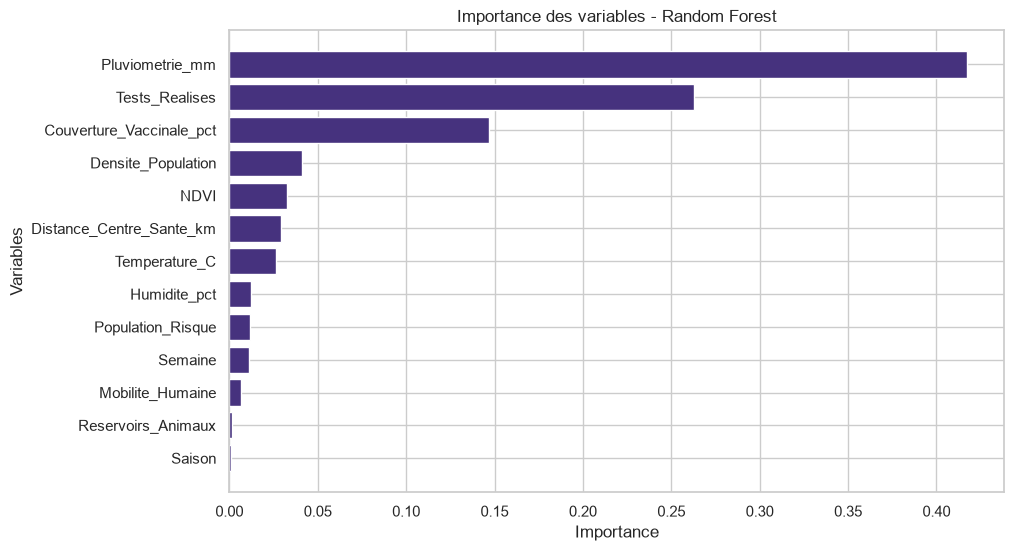

In [151]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Variable"],
    importance["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Variables")

plt.title("Importance des variables - Random Forest")

plt.gca().invert_yaxis()

plt.show()

Pluviométrie (42 %): represente la plus variable la plus influente. Cela signifie que les variations de la pluviométrie modifient fortement les prédictions du modèle.
ce qui  suggère que : la surveillance devrait être renforcée pendant les périodes de fortes pluies ;
les services sanitaires peuvent anticiper une augmentation potentielle des cas lorsque les conditions climatiques deviennent favorables.

Tests réalisés (26 %): Cette variable influence fortement le nombre de cas prédits.
Cela peut signifier que : les zones où davantage de tests sont réalisés détectent davantage de cas ; une faible capacité diagnostique peut conduire à une sous-estimation de l'épidémie. Alors il faudrait renforcer les capacités de dépistage permet une meilleure détection des cas.

Couverture vaccinale (15 %): Cette variable est également importante. Même si Random Forest ne donne pas le sens de l'effet, le modèle montre qu'elle joue un rôle important dans la prédiction. d'ou le renforcement de  la couverture vaccinale reste une stratégie prioritaire.



In [153]:
# Validation 

from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Scores R² :", scores)
print("R² moyen :", np.mean(scores))
print("Écart-type :", np.std(scores))

Scores R² : [0.82891545 0.84615558 0.84335662 0.85025175 0.88099354]
R² moyen : 0.8499345866171144
Écart-type : 0.017112064275214806


La validation croisée à cinq plis (5-fold cross-validation) a montré des coefficients de détermination compris entre 0,829 et 0,881, avec un R² moyen de 0,850 ± 0,017. Cette faible variabilité des performances traduit une bonne stabilité et une bonne capacité de généralisation du modèle Random Forest.

In [154]:
# Vérification de surapprentissage 
print("R² entraînement :", rf.score(X_train, y_train))
print("R² test :", rf.score(X_test, y_test)) 

R² entraînement : 0.9794565589520885
R² test : 0.8558964136063081


La comparaison des performances entre les données d'entraînement (R² = 0,979) et les données de test (R² = 0,856) met en évidence un léger surapprentissage. Toutefois, les performances restent élevées sur le jeu de test, ce qui indique que le modèle conserve une bonne capacité de généralisation.

#### Conclusion 

 Parmi les modèles évalués, Random Forest présente les meilleures performances prédictives avec un R² de 0,856, un RMSE de 27,782 et un MAE de 18,988. Il surpasse les modèles linéaires (régression linéaire, Ridge et Lasso), suggérant que les relations entre les variables environnementales, sanitaires et les cas confirmés comportent des composantes non linéaires. L'analyse de l'importance des variables montre que la pluviométrie, le nombre de tests réalisés et la couverture vaccinale sont les principaux déterminants des prédictions du modèle.